### GeoSafe — Data Preprocessing

### Geospatial Crime Hotspot Detection and Women Safety Risk Analysis

This notebook performs data understanding, data quality assessment, and preprocessing for the GeoSafe project.

The processed dataset will be used for:

1. Geospatial crime hotspot detection using clustering
2. Crime classification using four machine learning algorithms
3. Model evaluation and comparison
4. Women safety risk analysis based on crime patterns and identified hotspots
5. Integration of the machine learning results into the GeoSafe web application

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# LOAD DATSET

In [ ]:
df = pd.read_csv("Woman_Safety_Dataset_Management.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


# First dataset inspection

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20000
Number of columns: 15


In [ ]:
df.head()

,incident_id,city,area,latitude,longitude,crime_type,crime_count,time_of_day,lighting_score,police_station_distance_km,crowd_density,weather_condition,safety_score,risk_level,incident_timestamp
0,2b63f176-a5c9-4ac5-adbb-b81c14754ec4,Kolkata,Park Street,22.587501,88.359752,Domestic Violence,23,Afternoon,2.26,1.00,768,Stormy,0.85,Low,2025-05-14 12:40:25
1,ef4ba791-e5b5-4146-a3bb-c63e5d695e7c,Kolkata,Garia,22.565575,88.356876,Assault,4,Morning,1.84,2.01,626,Clear,0.92,Low,2024-11-02 08:14:54
2,6db79d9c-62d4-4c74-a2f2-295297dbc083,Bhopal,Kolar,23.242474,77.396845,Verbal Abuse,25,Afternoon,5.04,2.37,900,Clear,0.89,Low,2026-01-27 03:45:27
3,84fa6f88-339e-44b9-896a-6a548b8466c6,Mumbai,Kurla,18.997624,72.906211,Chain Snatching,19,Afternoon,2.94,6.16,114,Clear,0.58,Medium,2026-02-09 17:34:04
4,9e5035a9-0d9b-40fc-a1e8-21702c65096e,Jaipur,Malviya Nagar,26.899559,75.765028,Chain Snatching,56,Evening,6.43,6.50,757,Humid,0.42,High,2025-02-16 06:47:57


In [ ]:
df.columns.tolist()

['incident_id',
 'city',
 'area',
 'latitude',
 'longitude',
 'crime_type',
 'crime_count',
 'time_of_day',
 'lighting_score',
 'police_station_distance_km',
 'crowd_density',
 'weather_condition',
 'safety_score',
 'risk_level',
 'incident_timestamp']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   incident_id                 20000 non-null  object 
 1   city                        20000 non-null  object 
 2   area                        20000 non-null  object 
 3   latitude                    20000 non-null  float64
 4   longitude                   20000 non-null  float64
 5   crime_type                  20000 non-null  object 
 6   crime_count                 20000 non-null  int64  
 7   time_of_day                 20000 non-null  object 
 8   lighting_score              20000 non-null  float64
 9   police_station_distance_km  20000 non-null  float64
 10  crowd_density               20000 non-null  int64  
 11  weather_condition           20000 non-null  object 
 12  safety_score                20000 non-null  float64
 13  risk_level                  200

# Data Quality Check

In [ ]:
df.isnull().sum()

,0
incident_id,0
city,0
area,0
latitude,0
longitude,0
crime_type,0
crime_count,0
time_of_day,0
lighting_score,0
police_station_distance_km,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
incident_id,20000,20000,7b2392cc-9353-4848-9fca-c68beeed13d6,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,20000,10,Bhopal,2043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,20000,50,Indiranagar,443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,20000.0,NaN,NaN,NaN,21.625279,5.430797,12.874962,17.385593,23.188318,26.842789,28.718786
longitude,20000.0,NaN,NaN,NaN,79.419284,4.313909,72.764977,77.207536,77.669767,80.949044,88.460186
crime_type,20000,10,Night Safety Complaint,2047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crime_count,20000.0,NaN,NaN,NaN,32.35685,17.146166,0.0,18.0,32.0,46.0,85.0
time_of_day,20000,5,Night,4061,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lighting_score,20000.0,NaN,NaN,NaN,5.493725,2.592954,1.0,3.22,5.5,7.75,10.0
police_station_distance_km,20000.0,NaN,NaN,NaN,4.116744,2.23354,0.2,2.22,4.11,6.04,8.0


# Latitude/Longitude check

In [ ]:
df[["latitude", "longitude"]].describe()

,latitude,longitude
count,20000.000000,20000.000000
mean,21.625279,79.419284
std,5.430797,4.313909
min,12.874962,72.764977
25%,17.385593,77.207536
50%,23.188318,77.669767
75%,26.842789,80.949044
max,28.718786,88.460186


In [ ]:
df[["latitude", "longitude"]].isnull().sum()

,0
latitude,0
longitude,0


# Categorical Feature Analysis

### This section examines the unique values and frequency distribution of categorical features.

In [ ]:
categorical_columns = [
    "city",
    "area",
    "crime_type",
    "time_of_day",
    "weather_condition",
    "risk_level"
]

for col in categorical_columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print(df[col].value_counts())


Column: city
Number of unique values: 10
city
Bhopal       2043
Chennai      2026
Jaipur       2021
Mumbai       2019
Lucknow      2016
Patna        2015
Kolkata      2014
Bengaluru    2000
Delhi        1925
Hyderabad    1921
Name: count, dtype: int64

Column: area
Number of unique values: 50
area
Indiranagar        443
T Nagar            432
TT Nagar           428
Hazratganj         425
Danapur            424
Kukatpally         423
Gomti Nagar        418
Powai              417
Koramangala        415
Salt Lake          414
Andheri            414
Park Street        412
Vaishali Nagar     412
C Scheme           412
Habibganj          410
Arera Colony       410
Tambaram           409
Indira Nagar       407
Mansarovar         407
Howrah             406
Adyar              404
Rajendra Nagar     404
Malviya Nagar      403
Velachery          403
Patliputra         402
Bandra             402
Kankarbagh         401
Dadar              399
MP Nagar           398
Dwarka             398
Dum Dum   

## Geographic Coordinate Validation

Latitude and longitude are the primary features for geospatial crime hotspot detection.

In [ ]:
# Check valid latitude and longitude ranges

invalid_latitude = (
    (df["latitude"] < -90) |
    (df["latitude"] > 90)
).sum()

invalid_longitude = (
    (df["longitude"] < -180) |
    (df["longitude"] > 180)
).sum()

print("Invalid latitude values:", invalid_latitude)
print("Invalid longitude values:", invalid_longitude)

Invalid latitude values: 0
Invalid longitude values: 0


# Compare cities with coordinates

In [ ]:
city_summary = df.groupby("city").agg(
    records=("incident_id", "count"),
    avg_latitude=("latitude", "mean"),
    avg_longitude=("longitude", "mean")
).sort_values("records", ascending=False)

city_summary

,records,avg_latitude,avg_longitude
city,,,
Bhopal,2043,23.260068,77.413307
Chennai,2026,13.082656,80.271101
Jaipur,2021,26.912186,75.788694
Mumbai,2019,19.075153,72.877871
Lucknow,2016,26.846005,80.946911
Patna,2015,25.595101,85.136800
Kolkata,2014,22.572899,88.363533
Bengaluru,2000,12.970926,77.594001
Delhi,1925,28.614518,77.208336


# Convert timestamp

In [ ]:
df["incident_timestamp"] = pd.to_datetime(
    df["incident_timestamp"],
    errors="coerce"
)

print("Data type:", df["incident_timestamp"].dtype)
print("Invalid timestamps:", df["incident_timestamp"].isna().sum())

Data type: datetime64[ns]
Invalid timestamps: 0


In [ ]:
print("Earliest incident:", df["incident_timestamp"].min())
print("Latest incident:", df["incident_timestamp"].max())

Earliest incident: 2024-05-10 18:19:19
Latest incident: 2026-05-11 04:36:23


# Create useful time features

In [ ]:
df["incident_year"] = df["incident_timestamp"].dt.year
df["incident_month"] = df["incident_timestamp"].dt.month
df["incident_day"] = df["incident_timestamp"].dt.day
df["incident_hour"] = df["incident_timestamp"].dt.hour
df["incident_dayofweek"] = df["incident_timestamp"].dt.dayofweek

df[
    [
        "incident_timestamp",
        "incident_year",
        "incident_month",
        "incident_day",
        "incident_hour",
        "incident_dayofweek"
    ]
].head()

,incident_timestamp,incident_year,incident_month,incident_day,incident_hour,incident_dayofweek
0,2025-05-14 12:40:25,2025,5,14,12,2
1,2024-11-02 08:14:54,2024,11,2,8,5
2,2026-01-27 03:45:27,2026,1,27,3,1
3,2026-02-09 17:34:04,2026,2,9,17,0
4,2025-02-16 06:47:57,2025,2,16,6,6


# Check numerical feature ranges

In [ ]:
numerical_columns = [
    "latitude",
    "longitude",
    "crime_count",
    "lighting_score",
    "police_station_distance_km",
    "crowd_density",
    "safety_score"
]

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,20000.0,21.625279,5.430797,12.874962,17.385593,23.188318,26.842789,28.718786
longitude,20000.0,79.419284,4.313909,72.764977,77.207536,77.669767,80.949044,88.460186
crime_count,20000.0,32.356850,17.146166,0.000000,18.000000,32.000000,46.000000,85.000000
lighting_score,20000.0,5.493725,2.592954,1.000000,3.220000,5.500000,7.750000,10.000000
police_station_distance_km,20000.0,4.116744,2.233540,0.200000,2.220000,4.110000,6.040000,8.000000
crowd_density,20000.0,505.148050,284.978533,10.000000,259.000000,502.000000,750.000000,1000.000000
safety_score,20000.0,0.714330,0.219358,0.000000,0.560000,0.730000,0.900000,1.000000


# Check the classification target

risk_level
Low         9301
Medium      6940
High        3260
Critical     499
Name: count, dtype: int64


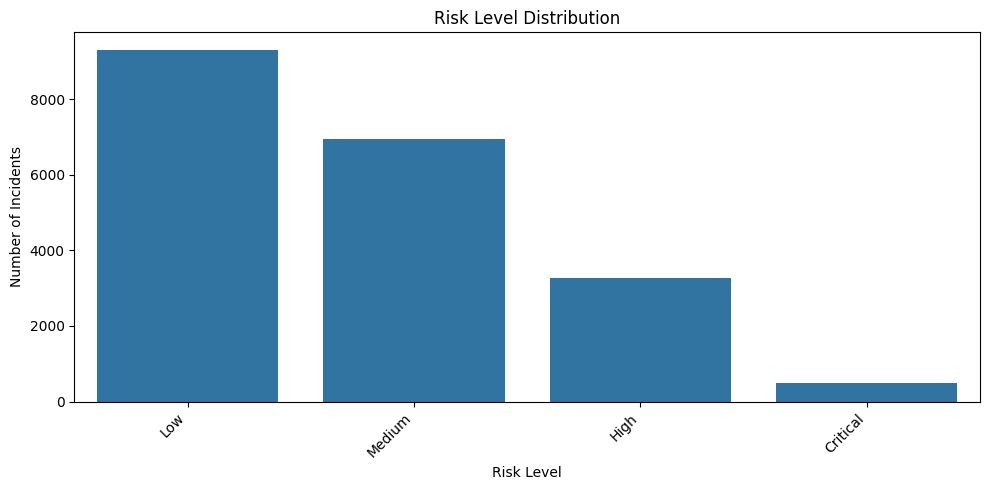

In [ ]:
crime_distribution = df["risk_level"].value_counts()

print(crime_distribution)

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="risk_level",
    order=df["risk_level"].value_counts().index
)

plt.xticks(rotation=45, ha="right")
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()

# Create a cleaned dataset

In [ ]:
df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (20000, 20)
Cleaned dataset shape: (20000, 20)
